In [11]:
!pip install prophet

  Using cached holidays-0.89-py3-none-any.whl.metadata (50 kB)
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB 4.0 MB/s eta 0:00:03
   --- ------------------------------------ 1.1/12.1 MB 9.7 MB/s eta 0:00:02
   ------- -------------------------------- 2.3/12.1 MB 14.5 MB/s eta 0:00:01
   ----------- ---------------------------- 3.4/12.1 MB 16.7 MB/s eta 0:00:01
   --------------- ------------------------ 4.6/12.1 MB 18.6 MB/s eta 0:00:01
   ------------------ --------------------- 5.6/12.1 MB 19.9 MB/s eta 0:00:01
   ---------------------- ----------------- 6.9/12.1 MB 20.1 MB/s eta 0:00:01
   --------------------------- ------------ 8.3/12.1 MB 21.2 MB/s eta 0:00:01
   ---------------------------- ----------- 8.7/12.1 MB 19.9 MB/s eta 0:00:01
   --------------------------------- ------ 10.0/12.1 MB 21.4 MB/s eta 0:00:01
   ---------------

In [65]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [177]:
df = yf.download('HDFCBANK.NS', start='2020-01-01', end='2026-01-30')['Close']
df

[*********************100%***********************]  1 of 1 completed


Ticker,HDFCBANK.NS
Date,
2020-01-01,605.529419
2020-01-02,609.389160
2020-01-03,600.698730
2020-01-06,587.698792
2020-01-07,597.004761
...,...
2026-01-22,918.700012
2026-01-23,916.099976
2026-01-27,926.400024


In [179]:
from prophet import Prophet

In [181]:
model = Prophet()
model

In [183]:
df = df.reset_index()
df

Ticker,Date,HDFCBANK.NS
0,2020-01-01,605.529419
1,2020-01-02,609.389160
2,2020-01-03,600.698730
3,2020-01-06,587.698792
4,2020-01-07,597.004761
...,...,...
1502,2026-01-22,918.700012
1503,2026-01-23,916.099976
1504,2026-01-27,926.400024
1505,2026-01-28,932.700012


In [187]:
df[['ds','y']] = df[['Date','HDFCBANK.NS']]

df

Ticker,Date,HDFCBANK.NS,ds,y
0,2020-01-01,605.529419,2020-01-01,605.529419
1,2020-01-02,609.389160,2020-01-02,609.389160
2,2020-01-03,600.698730,2020-01-03,600.698730
3,2020-01-06,587.698792,2020-01-06,587.698792
4,2020-01-07,597.004761,2020-01-07,597.004761
...,...,...,...,...
1502,2026-01-22,918.700012,2026-01-22,918.700012
1503,2026-01-23,916.099976,2026-01-23,916.099976
1504,2026-01-27,926.400024,2026-01-27,926.400024
1505,2026-01-28,932.700012,2026-01-28,932.700012


In [189]:
model.fit(df)

23:21:32 - cmdstanpy - INFO - Chain [1] start processing
23:21:33 - cmdstanpy - INFO - Chain [1] done processing


In [190]:
future = model.make_future_dataframe(periods=120)

In [193]:
forecast = model.predict(future)

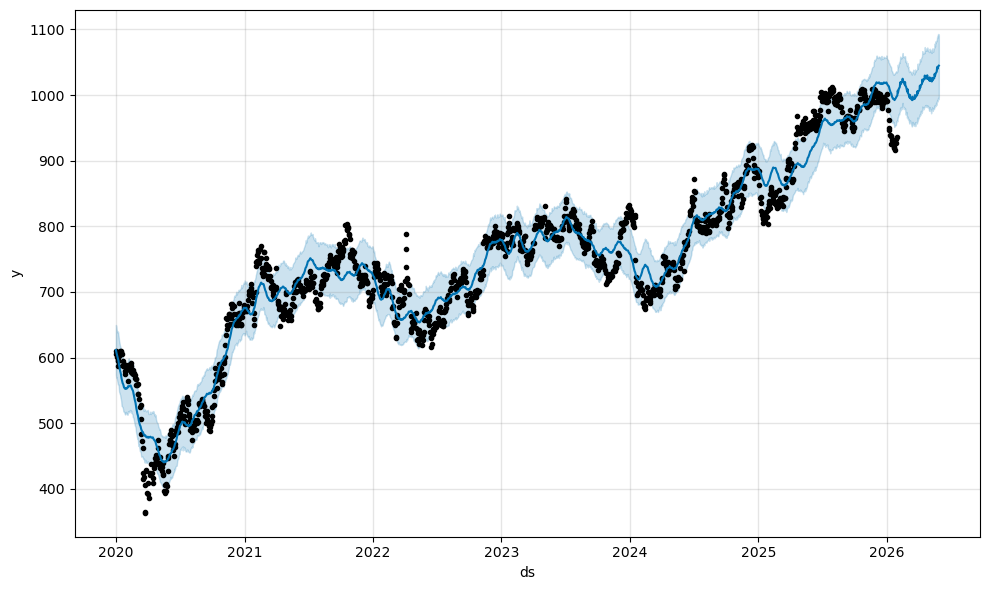

In [195]:
model.plot(forecast)
plt.show()